---

# Training VAE

>Conditional VAE that jointly trains encoder, decoder, and geotag-to-latent MLP.
>Audio is 1 second at 44100 Hz.

---

In [19]:
import os
import sys
sys.path.insert(0, os.path.join('..'))

import numpy as np
import pandas as pd
import tensorflow as tf
import IPython.display as ipd
import matplotlib.pyplot as plt
from models.vae import VAE

CACHE_DIR = os.path.join('..', '.cache')
WEIGHTS_DIR = os.path.join('..', 'models', 'weights')

## Load dataset

In [20]:
from scipy.signal import resample
from models.vae import CHUNK_SIZE

audio = np.load(os.path.join(CACHE_DIR, 'audio.npy'))
df = pd.read_csv(os.path.join(CACHE_DIR, 'mappings.csv'))

if audio.shape[1] != CHUNK_SIZE:
    audio = resample(audio, CHUNK_SIZE, axis=1).astype(np.float32)

audio = np.clip(audio, -1.0, 1.0)

print(f'Audio shape: {audio.shape}')
print(f'Mappings shape: {df.shape}')
df.head()

Audio shape: (5000, 2048)
Mappings shape: (5000, 3)


,path,lat,long
0,../.cache/audio/33716.mp3,0.372981,-0.566150
1,../.cache/audio/33531.mp3,0.457793,0.051874
2,../.cache/audio/33530.mp3,0.457793,0.051874
3,../.cache/audio/33529.mp3,0.457793,0.051874
4,../.cache/audio/33521.mp3,0.583121,-0.011643


In [21]:
geotags = df[['lat', 'long']].to_numpy()
print(f'Geotags shape: {geotags.shape}')

Geotags shape: (5000, 2)


In [22]:
with tf.device('/CPU:0'):
    dataset = tf.data.Dataset.from_tensor_slices((audio.astype(np.float32), geotags.astype(np.float32)))
dataset = dataset.shuffle(buffer_size=1024).batch(8).prefetch(tf.data.AUTOTUNE)

## Build model

In [23]:
print('Devices:', tf.config.list_physical_devices('GPU'))

Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
vae = VAE(latent_dim=64, recon_weight=1.0, kl_weight=0.5, mlp_weight=1.0)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

# Warmup: train encoder+decoder only, freeze MLP
vae.mlp.trainable = False

# Build model with dummy forward pass
_dummy_audio = tf.zeros((1, 2048))
_dummy_geo = tf.zeros((1, 2))
vae([_dummy_audio, _dummy_geo])

# KL annealing: ramp from 0 to target over first 10 epochs
KL_ANNEAL_EPOCHS = 10

warmup_history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}
for epoch in range(20):
    kl_w = min(1.0, (epoch + 1) / KL_ANNEAL_EPOCHS) * vae.kl_weight
    vae.current_kl_weight.assign(kl_w)
    h = vae.fit(dataset, epochs=1, verbose=1)
    for k in warmup_history:
        warmup_history[k].append(h.history[k][0])
    print(f'  kl_weight={kl_w:.4f}')

Model: "vae_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_2 (Encoder)         multiple                  1445248   
                                                                 
 decoder_2 (Decoder)         multiple                  567680    
                                                                 
 mlp_2 (MLP)                 multiple                  82688     
                                                                 
Total params: 2,095,624
Trainable params: 2,012,928
Non-trainable params: 82,696
_________________________________________________________________


## Train encoder+decoder (warmup)

In [25]:
history_warmup = vae.fit(dataset, epochs=20)

Epoch 1/20
625/625 [==============================] - 3s 4ms/step - total_loss: 0.5152 - recon_loss: 0.0394 - kl_loss: 20.2601 - mlp_loss: 0.2732
Epoch 2/20
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4973 - recon_loss: 0.0391 - kl_loss: 20.9967 - mlp_loss: 0.2482
Epoch 3/20
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4955 - recon_loss: 0.0391 - kl_loss: 20.9790 - mlp_loss: 0.2466
Epoch 4/20
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4942 - recon_loss: 0.0391 - kl_loss: 20.9242 - mlp_loss: 0.2458
Epoch 5/20
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4962 - recon_loss: 0.0391 - kl_loss: 21.0865 - mlp_loss: 0.2462
Epoch 6/20
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4948 - recon_loss: 0.0391 - kl_loss: 21.0130 - mlp_loss: 0.2455
Epoch 7/20
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4952 - recon_loss: 0.0391 - kl_loss: 21.08

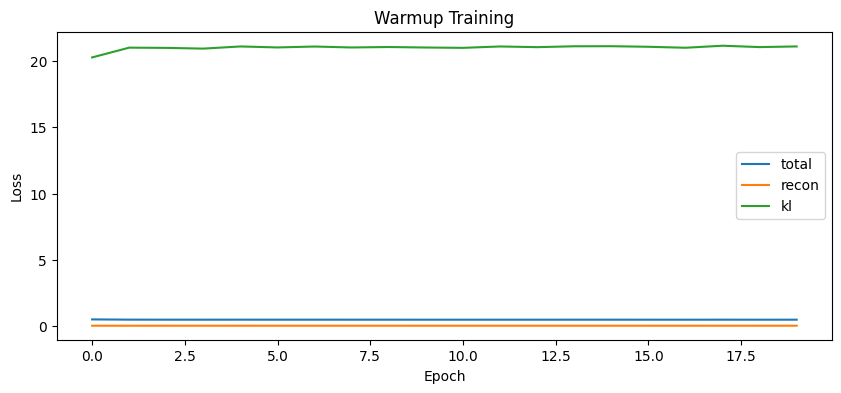

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(warmup_history['total_loss'], label='total')
plt.plot(warmup_history['recon_loss'], label='recon')
plt.plot(warmup_history['kl_loss'], label='kl')
plt.legend()
plt.title('Warmup Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Test reconstruction

In [27]:
idx = np.random.randint(len(audio))
sample_audio = audio[idx:idx+1].astype(np.float32)
sample_geo = geotags[idx:idx+1].astype(np.float32)

mu, logvar = vae.encoder(sample_audio)
z = vae.reparameterize(mu, logvar)
recon = vae.decoder(z).numpy()[0]

print('Original:')
ipd.display(ipd.Audio(sample_audio[0], rate=44100))
print('Reconstructed:')
ipd.display(ipd.Audio(recon, rate=44100))

Original:


Reconstructed:


## Train full model (joint training)

In [ ]:
vae.mlp.trainable = True
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))
vae.current_kl_weight.assign(vae.kl_weight)

history_joint = vae.fit(dataset, epochs=50)

Epoch 1/50
625/625 [==============================] - 3s 4ms/step - total_loss: 0.4929 - recon_loss: 0.0391 - kl_loss: 21.0881 - mlp_loss: 0.2429
Epoch 2/50
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4928 - recon_loss: 0.0391 - kl_loss: 21.1069 - mlp_loss: 0.2426
Epoch 3/50
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4934 - recon_loss: 0.0391 - kl_loss: 21.1561 - mlp_loss: 0.2427
Epoch 4/50
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4935 - recon_loss: 0.0391 - kl_loss: 21.1546 - mlp_loss: 0.2429
Epoch 5/50
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4927 - recon_loss: 0.0391 - kl_loss: 21.0924 - mlp_loss: 0.2427
Epoch 6/50
625/625 [==============================] - 2s 4ms/step - total_loss: 0.4921 - recon_loss: 0.0391 - kl_loss: 21.0618 - mlp_loss: 0.2424
Epoch 7/50
625/625 [==============================] - 3s 4ms/step - total_loss: 0.4916 - recon_loss: 0.0391 - kl_loss: 21.02

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_joint.history['total_loss'], label='total')
plt.plot(history_joint.history['recon_loss'], label='recon')
plt.plot(history_joint.history['kl_loss'], label='kl')
plt.plot(history_joint.history['mlp_loss'], label='mlp')
plt.legend()
plt.title('Joint Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Test generation from geotag

In [ ]:
test_geotag = np.array([[0.5, 0.0]]).astype(np.float32)
generated = vae.generate(test_geotag).numpy()[0]

print('Generated from geotag (0.5, 0.0):')
ipd.display(ipd.Audio(generated, rate=44100))

## Save weights

In [ ]:
vae.encoder.save_weights(os.path.join(WEIGHTS_DIR, 'encoder.h5'))
vae.decoder.save_weights(os.path.join(WEIGHTS_DIR, 'decoder.h5'))
vae.mlp.save_weights(os.path.join(WEIGHTS_DIR, 'mlp.h5'))
print('Weights saved.')

## Compare with old models

In [ ]:
from scipy.interpolate import interp1d

SAMPLE_RATE = 44100

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def generate_path(geotags_path, speed=40):
    """Generate audio for a path of geotags."""
    all_audio = []
    for i in range(len(geotags_path) - 1):
        g1 = geotags_path[i:i+1].astype(np.float32)
        g2 = geotags_path[i+1:i+2].astype(np.float32)
        
        # Interpolate 200 points
        lats = np.linspace(g1[0,0], g2[0,0], 200)
        lngs = np.linspace(g1[0,1], g2[0,1], 200)
        path_geotags = np.stack([lats, lngs], axis=1).astype(np.float32)
        
        # Generate audio for each point
        segment_audio = []
        for g in path_geotags:
            g_batch = g[np.newaxis, :]
            audio_chunk = vae.generate(g_batch).numpy()[0]
            segment_audio.append(audio_chunk)
        
        segment = np.concatenate(segment_audio)
        
        # Resample to target duration
        dist = haversine(g1[0,0], g1[0,1], g2[0,0], g2[0,1])
        target_duration = dist / speed
        target_samples = int(target_duration * SAMPLE_RATE)
        
        if target_samples > 0 and target_samples != len(segment):
            x_old = np.linspace(0, 1, len(segment))
            x_new = np.linspace(0, 1, target_samples)
            f = interp1d(x_old, segment, kind='linear')
            segment = f(x_new)
        
        all_audio.append(segment)
    
    return np.concatenate(all_audio)

# Test: USA to India
path = np.array([
    [39.8, -98.5],   # USA center
    [20.6, 42.0],    # Saudi Arabia
    [21.0, 78.0],    # India
])

audio_out = generate_path(path)
print(f'Generated {len(audio_out)/SAMPLE_RATE:.1f}s of audio')
ipd.display(ipd.Audio(audio_out, rate=SAMPLE_RATE))